In [4]:
train_path='E:/Rasengan/horse-or-human/train'
test_path='E:/Rasengan/horse-or-human/validation'

In [5]:
import tensorflow as tf

In [6]:
img_size=(180,180)
batch_size=32

In [8]:
train_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True
)
val_data = tf.keras.utils.image_dataset_from_directory(
    train_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=True
)
test_data = tf.keras.utils.image_dataset_from_directory(
    test_path,
    image_size=img_size,
    batch_size=batch_size,
    color_mode='rgb',
    shuffle=False
)

Found 1027 files belonging to 2 classes.
Using 822 files for training.
Found 1027 files belonging to 2 classes.
Using 205 files for validation.
Found 256 files belonging to 2 classes.


In [9]:
from tensorflow.keras import Sequential
from tensorflow.keras import layers

In [10]:
model = Sequential([
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),

    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(2, activation="softmax")
])

C:\Users\moury\anaconda3\envs\ai-ml\lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history=model.fit(train_data, validation_data=val_data, epochs=10)

Epoch 1/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 7s 219ms/step - accuracy: 0.7287 - loss: 0.6381 - val_accuracy: 0.9122 - val_loss: 0.2387
Epoch 2/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.9550 - loss: 0.1320 - val_accuracy: 0.9707 - val_loss: 0.0815
Epoch 3/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 213ms/step - accuracy: 0.9854 - loss: 0.0389 - val_accuracy: 0.9854 - val_loss: 0.0239
Epoch 4/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 214ms/step - accuracy: 0.9866 - loss: 0.0472 - val_accuracy: 0.9805 - val_loss: 0.0561
Epoch 5/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 218ms/step - accuracy: 0.9939 - loss: 0.0204 - val_accuracy: 0.9902 - val_loss: 0.0386
Epoch 6/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 225ms/step - accuracy: 0.9927 - loss: 0.0173 - val_accuracy: 0.9951 - val_loss: 0.0395
Epoch 7/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 221ms/step - accuracy: 1.0000 - loss: 0.0051 - val_accuracy: 0.9951 - val_loss: 0.0200
Epoch 8/10
26/26 ━━━━━━━━━━━━━━━━━━━━ 6s 223ms/step - accuracy: 0.9976 - loss: 0.0068 - val_accuracy: 0.

In [13]:
test_loss, test_acc = model.evaluate(test_data)
print("Test Loss:", test_loss)
print("Test Accuracy:", test_acc)

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8008 - loss: 3.4439
Test Loss: 3.4439172744750977
Test Accuracy: 0.80078125


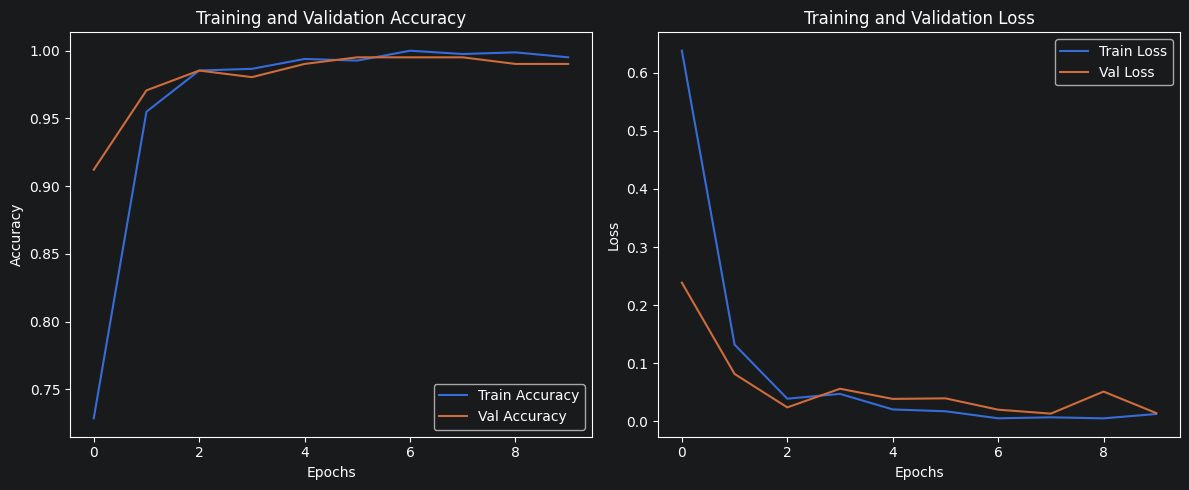

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

# Loss graph
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.tight_layout()
plt.show()

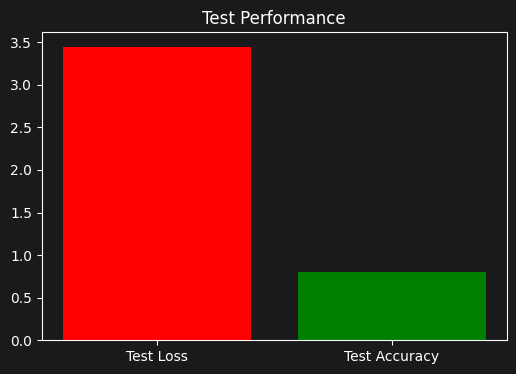

In [15]:
plt.figure(figsize=(6, 4))
plt.bar(['Test Loss', 'Test Accuracy'], [test_loss, test_acc], color=['red', 'green'])
plt.title('Test Performance')
plt.show()